In [150]:
import numpy as np, matplotlib.pyplot as plt
%matplotlib widget

In [260]:
### pair up Equal Evolutionary Point (EEP) values with the phases, per Table 2 in 
### the detailed information PDF at https://mist.science/resources.html
eep_vals_all = np.array([1, 202, 353, 454, 605, 631, 707, 808, 1409, 1710])
eeps_low_mass = eep_vals_all[0:10] # for low-mass stars
eeps_high_mass = eep_vals_all[0:8] # for high-mass stars
eep_names_all = ['pre-MS', 'ZAMS', 'IAMS', 'TAMS', 'RGB tip']
eep_names_low_mass = eep_names_all + ['ZAHB', 'TAHB', 'TP-AGB', 'post-AGB', 'WDCS']
eep_names_high_mass = eep_names_all + ['ZACHeB', 'TACHeB', 'C-burn']

In [298]:
star = 'HD 278555'
eep_ndx = (1,3)
eep_names = [eep_names_low_mass[i] for i in eep_ndx]
eep_vals = [eeps_low_mass[i] for i in eep_ndx]
#eep_names = eep_names_high_mass
#eep_vals = eeps_high_mass
tefftrack, rstartrack, agetrack, loggtrack, eeptrack = np.loadtxt('10.iso-only.rho-table2-prior/10.iso-only.rho-table2-prior.mcmc.mist.000.track.txt',unpack=True)
mass, teff, logg, eep, age, teff_bf, logg_bf, eep_bf, age_bf = np.loadtxt('10.iso-only.rho-table2-prior/10.iso-only.rho-table2-prior.mcmc.mist.000.nearest_vs_best.txt',unpack=True)

In [303]:
if (eep + 3) > max(eeptrack):
    mineep = 1
else: mineep = 202
ndx = np.where((loggtrack > 3) & (loggtrack < 5) & (eeptrack >= min([mineep,eep])))[0]
ages = agetrack#[ndx]
eeptrack = eeptrack#[ndx]
xmin = max(list(tefftrack[ndx]),[teff*1.1], [teff*0.75])[0]
xmax = min(list(tefftrack[ndx]),[teff*1.1], [teff*0.75])[0]
ymax = min(list(loggtrack[ndx]),[3],[5],[logg])[0]
ymin = max(list(loggtrack[ndx]),[3],[5],[logg])[0]

[junk1, eep_ndx, name_ndx] = np.intersect1d(eeptrack, eep_vals, return_indices=True)
print(eep_ndx, name_ndx)
print(eep, age, eep_bf, age_bf)
for i in range(len(eep_ndx)):
    if ages[eep_ndx[i]] < 1: # convert from Gyr to Myr
        age_txt[i] =  eep_names[i] + '\n' + f'{ages[eep_ndx[i]]*1e3:.2f}' + ' Myr'
    else:
        age_txt[i] =  eep_names[i] + '\n' + f'{ages[eep_ndx[i]]:.2f}' + ' Gyr'
print(np.log10(tefftrack[eep_ndx]),loggtrack[eep_ndx])

[201 453] [0 1]
385.0 3.26747 385.29716 3.27558
[3.78014243 3.76403473] [4.37528 3.88571]


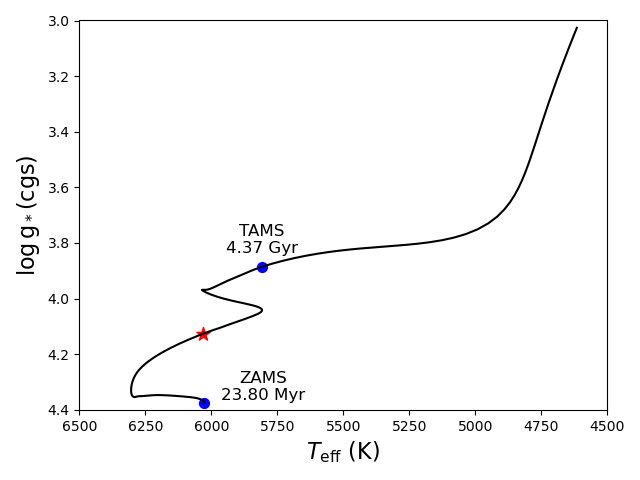

In [330]:
plt.close('all')
fig = plt.figure(1)#,figsize=(6,7))
plt.plot(tefftrack[ndx],loggtrack[ndx],c='k')
#plt.plot(tefftrack[:],loggtrack[:],c='k')
plt.scatter(teff,logg,color='red',marker='*',s=100)
plt.scatter(tefftrack[eep_ndx], loggtrack[eep_ndx],color='blue',s=50)
for i in range(len(eep_ndx)):
    eep_tmp = eep_ndx[i]
    offset = np.zeros((len(eep_ndx),2))
    offset[0] = (-225,-0.01)
    offset[1] = (0,-0.05) 
    plt.annotate(age_txt[i],(tefftrack[eep_tmp]+offset[i][0], loggtrack[eep_tmp]+offset[i][1]),color='k',fontsize=12, ha='center')
plt.xlim(6500,4500)
plt.ylim(4.4,ymax)
#plt.xlim(6500,5900)
#plt.ylim(4.38,4.3)
plt.xlabel(r'$T_{\rm eff}~ {\rm (K)}$',fontsize=16)
plt.ylabel(r'$\log {\rm g_*(cgs)}$',fontsize=16)
plt.tight_layout()
plt.show()
#plt.savefig(star+'.mist.pretty.pdf')
#plt.savefig(star+'.mist.pretty.ps')